2 Getting Started with Image Processing with Python.



Introduction to Python Imaging Library(PIL)

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

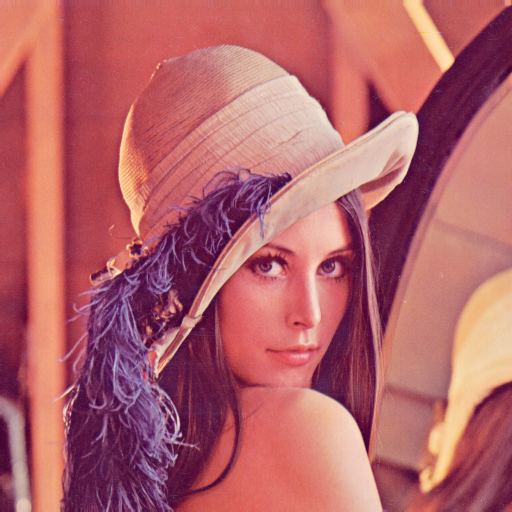

In [57]:
# Read the image
img = Image.open("/content/drive/MyDrive/AI and ML/Lenna_image.png")

# Display the image
display ( img )

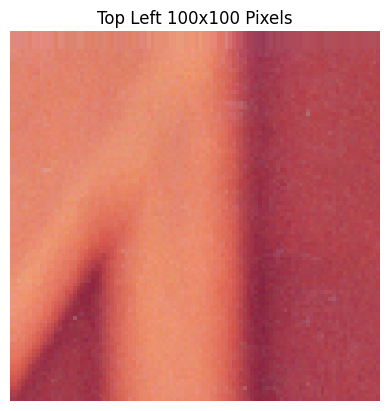

In [58]:
# Convert image to numpy array
img_array = np.array(img)

# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display the extracted portion
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

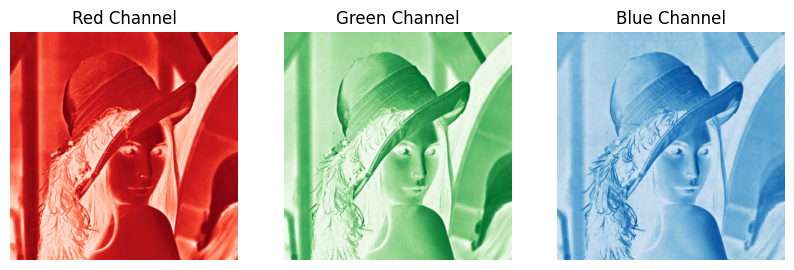

In [59]:

img = Image.open("/content/drive/MyDrive/AI and ML/Lenna_image.png")


# Separate color channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display each channel
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

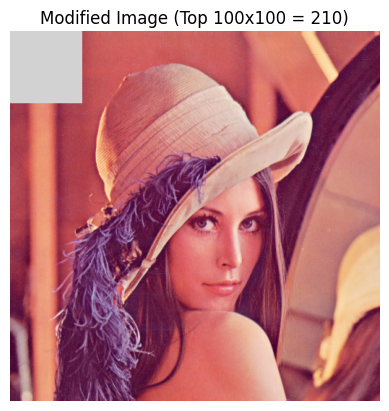

In [60]:
img = Image.open("/content/drive/MyDrive/AI and ML/Lenna_image.png")

# Convert to numpy array
img_array = np.array(img)

# Modify the top-left 100x100 pixels
img_array[0:100, 0:100] = 210

# Display the modified image
plt.imshow(img_array)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

2.2 Exercise - 2:

In [61]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

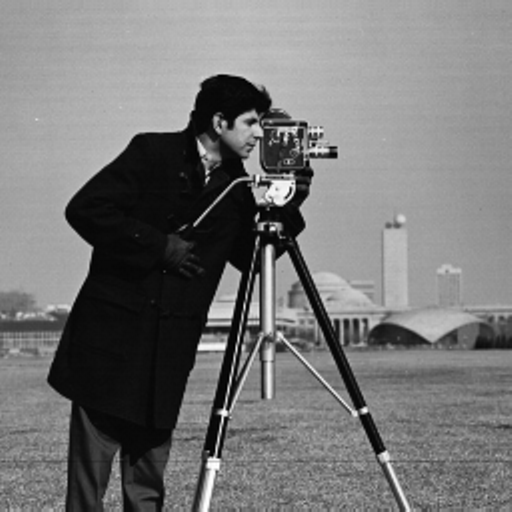

In [62]:
grayscale_img = Image. open("/content/drive/MyDrive/AI and ML/cameraman.png")

display(grayscale_img)

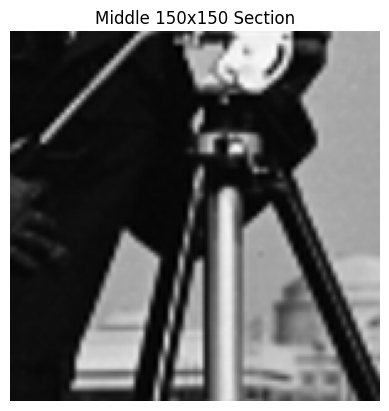

In [63]:
# Convert image to numpy array
img_array = np.array(grayscale_img)

# Get image size
h, w = img_array.shape

# Find center
center_h = h // 2
center_w = w // 2

# Extract 150x150 middle section
middle_section = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display cropped section
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

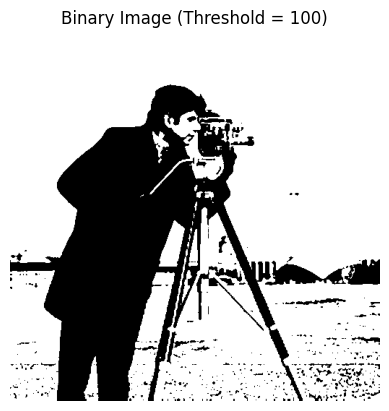

In [64]:
binary_img = np.where(img_array < 100, 0, 255)

plt.imshow(binary_img, cmap='gray')
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

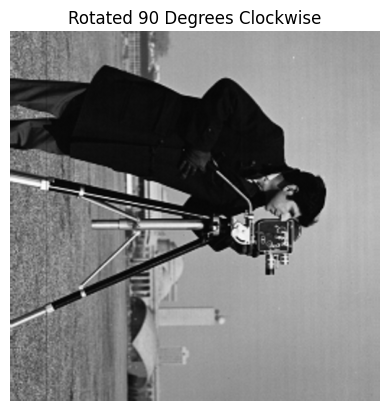

In [65]:
rotated_img = np.rot90(img_array, -1)

plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

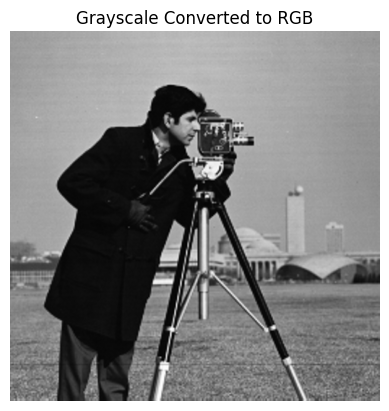

In [66]:
rgb_image = np.stack((img_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

3 Image Compression and Decompression using PCA.

In [67]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

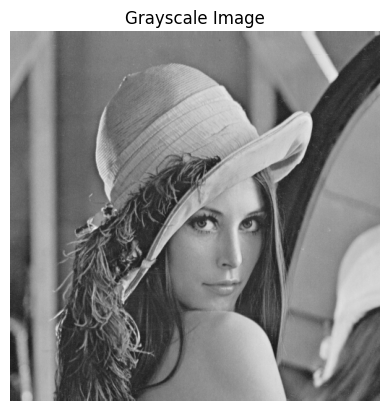

In [68]:
# Load image
gray_img = Image.open("/content/drive/MyDrive/AI and ML/lena_gray.gif")


# Display grayscale image
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

In [69]:
# Convert image to a numpy array
img_array = np.array(gray_img, dtype=np.float64)

# 1. Standardize
# Calculate the mean of each column and subtract it from the data
mean_vec = np.mean(img_array, axis=0)
X_centered = img_array - mean_vec

# Calculate the covariance matrix
# rowvar=False treats columns as variables (features) and rows as observations
cov_matrix = np.cov(X_centered, rowvar=False)

print(f"Shape of centered data: {X_centered.shape}")
print(f"Shape of covariance matrix: {cov_matrix.shape}")

Shape of centered data: (512, 512)
Shape of covariance matrix: (512, 512)


In [70]:
# 2. Compute Eigenvalues and Eigenvectors

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort the eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:", eigenvalues)
print("Corresponding Eigenvectors shape:", eigenvectors.shape)



Sorted Eigenvalues: [ 1.04348099e+05  6.35049578e+04  3.75163258e+04  3.57567156e+04
  2.78230181e+04  2.15305865e+04  1.83200580e+04  1.60498591e+04
  1.52462922e+04  1.40783495e+04  1.37744276e+04  1.32013577e+04
  1.28988721e+04  1.25665299e+04  1.20718589e+04  1.20044412e+04
  1.18613594e+04  1.16286170e+04  1.15267149e+04  1.13295343e+04
  1.10754861e+04  1.10072280e+04  1.08987281e+04  1.06368102e+04
  1.06144173e+04  1.05497128e+04  1.04537881e+04  1.02864828e+04
  1.02341879e+04  1.00188731e+04  1.00083559e+04  9.95192558e+03
  9.84288319e+03  9.71094705e+03  9.65175746e+03  9.55989041e+03
  9.53728620e+03  9.45568125e+03  9.35618963e+03  9.25998550e+03
  9.12867993e+03  9.11758913e+03  9.10330101e+03  9.02142140e+03
  8.96724763e+03  8.88383612e+03  8.85727016e+03  8.78334775e+03
  8.69219501e+03  8.64184661e+03  8.61543304e+03  8.52571374e+03
  8.46816196e+03  8.41689929e+03  8.40017594e+03  8.32072549e+03
  8.27999069e+03  8.24531756e+03  8.19033846e+03  8.08260891e+03
  8.0

In [71]:
# Calculate explained variance and cumulative variance
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)



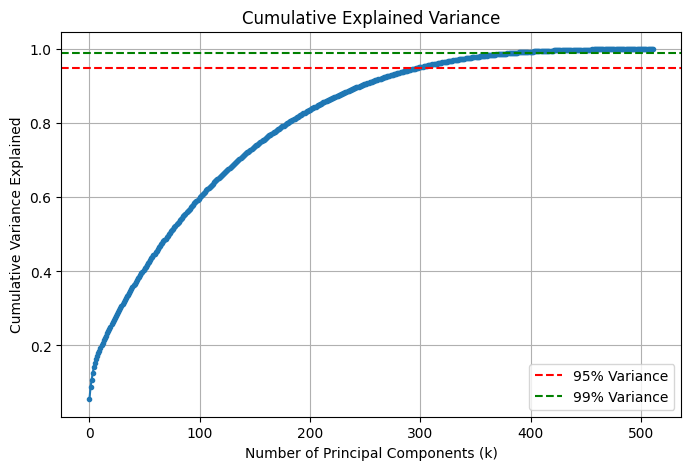

In [72]:
# Plot the cumulative sum to identify Principal Components
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='.', linestyle='-')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components (k)')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% Variance')
plt.legend()
plt.show()

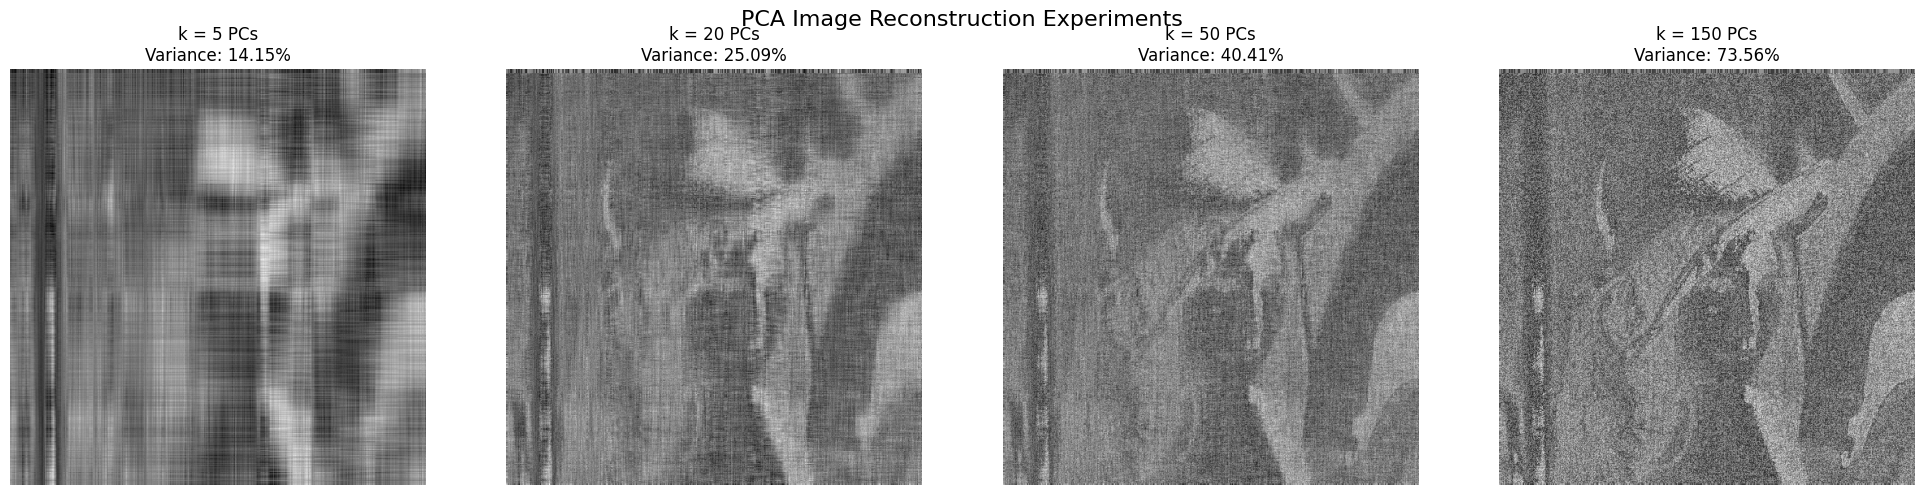

In [73]:
# 3. Reconstruction and Experiment

def reconstruct_image(k):
    """Transforms data to lower dimensions and reconstructs it."""
    # Choose top k eigenvectors
    top_k_eigenvectors = eigenvectors[:, :k]

    # Transform original data (Lower-dimensional representation)
    lower_dimensional_data = np.dot(X_centered, top_k_eigenvectors)

    # Reconstruct the data back to original dimensions
    reconstructed_data = np.dot(lower_dimensional_data, top_k_eigenvectors.T) + mean_vec
    return reconstructed_data

# Pick four different combinations of principal components (k)
# You can adjust these numbers based on your cumulative sum plot!
k_values = [5, 20, 50, 150]

# Display the results side-by-side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, k in enumerate(k_values):
    # Reconstruct image
    reconstructed_img = reconstruct_image(k)

    # Get the variance explained by this specific k
    var_explained = cumulative_variance[k-1] * 100

    # Plot
    axes[i].imshow(reconstructed_img, cmap='gray')
    axes[i].set_title(f"k = {k} PCs\nVariance: {var_explained:.2f}%")
    axes[i].axis('off')

plt.suptitle("PCA Image Reconstruction Experiments", fontsize=16)
plt.tight_layout()
plt.show()